# SUBCLU-style Clustering (Glass Dataset)


In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

In [43]:
#LOAD DATA
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = "/content/drive/MyDrive/Colab_Notebooks/SUBCLU/glass.csv"
df = pd.read_csv(FILE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
df.head()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type of glass
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [45]:
df.shape
print("Number of raws:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of raws: 214
Number of columns: 11


In [46]:
df.describe()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type of glass
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,107.500000,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,61.920648,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.000000,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,54.250000,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,107.500000,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,160.750000,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,214.000000,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [47]:
# Checking the null values of the Data set
df.isnull().sum()

,0
Id,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0


In [50]:
# Check for duplicates
duplicates = df.duplicated()
print("Number of Duplicates:", duplicates.sum())

Number of Duplicates: 0


In [51]:
# Keep original labels for evaluation
df_original = df.copy()
true_labels = df_original['Type of glass']

In [52]:
# Drop non-feature columns
df = df.drop(columns=['Id', 'Type of glass'])

In [53]:
df.shape
print("Number of raws:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of raws: 214
Number of columns: 9


In [29]:
# Scale features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

features = df.columns.tolist()
print('Features:', features)

Features: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']


## 1D Subspaces

In [30]:
valid_1d = []
for f in features:
    X = df_scaled[[f]]
    labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 0:
        valid_1d.append(f)
    print(f'{f}: clusters = {n_clusters}')

print('Valid 1D features:', valid_1d)

RI: clusters = 1
Na: clusters = 2
Mg: clusters = 1
Al: clusters = 1
Si: clusters = 2
K: clusters = 1
Ca: clusters = 1
Ba: clusters = 2
Fe: clusters = 1
Valid 1D features: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']


## 2D Subspaces

In [31]:
valid_2d = []
plot_data = []

for combo in itertools.combinations(valid_1d, 2):
    X = df_scaled[list(combo)]
    labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 0:
        valid_2d.append(combo)
        plot_data.append((combo, X, labels, n_clusters))

    print(f'{combo}: clusters = {n_clusters}')

('RI', 'Na'): clusters = 1
('RI', 'Mg'): clusters = 2
('RI', 'Al'): clusters = 2
('RI', 'Si'): clusters = 1
('RI', 'K'): clusters = 2
('RI', 'Ca'): clusters = 2
('RI', 'Ba'): clusters = 5
('RI', 'Fe'): clusters = 2
('Na', 'Mg'): clusters = 2
('Na', 'Al'): clusters = 2
('Na', 'Si'): clusters = 1
('Na', 'K'): clusters = 1
('Na', 'Ca'): clusters = 1
('Na', 'Ba'): clusters = 4
('Na', 'Fe'): clusters = 2
('Mg', 'Al'): clusters = 3
('Mg', 'Si'): clusters = 2
('Mg', 'K'): clusters = 2
('Mg', 'Ca'): clusters = 3
('Mg', 'Ba'): clusters = 3
('Mg', 'Fe'): clusters = 2
('Al', 'Si'): clusters = 1
('Al', 'K'): clusters = 1
('Al', 'Ca'): clusters = 2
('Al', 'Ba'): clusters = 3
('Al', 'Fe'): clusters = 1
('Si', 'K'): clusters = 1
('Si', 'Ca'): clusters = 2
('Si', 'Ba'): clusters = 4
('Si', 'Fe'): clusters = 2
('K', 'Ca'): clusters = 1
('K', 'Ba'): clusters = 3
('K', 'Fe'): clusters = 1
('Ca', 'Ba'): clusters = 3
('Ca', 'Fe'): clusters = 1
('Ba', 'Fe'): clusters = 3


## 3D Subspaces

In [33]:
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

valid_3d = []
plot_data_3d = []

for combo in itertools.combinations(valid_1d, 3):
    X = df_scaled[list(combo)]
    labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 0:
        valid_3d.append(combo)
        plot_data_3d.append((combo, X, labels, n_clusters))

    print(f'{combo}: clusters = {n_clusters}')

('RI', 'Na', 'Mg'): clusters = 2
('RI', 'Na', 'Al'): clusters = 6
('RI', 'Na', 'Si'): clusters = 3
('RI', 'Na', 'K'): clusters = 1
('RI', 'Na', 'Ca'): clusters = 4
('RI', 'Na', 'Ba'): clusters = 3
('RI', 'Na', 'Fe'): clusters = 2
('RI', 'Mg', 'Al'): clusters = 3
('RI', 'Mg', 'Si'): clusters = 3
('RI', 'Mg', 'K'): clusters = 4
('RI', 'Mg', 'Ca'): clusters = 4
('RI', 'Mg', 'Ba'): clusters = 5
('RI', 'Mg', 'Fe'): clusters = 3
('RI', 'Al', 'Si'): clusters = 2
('RI', 'Al', 'K'): clusters = 4
('RI', 'Al', 'Ca'): clusters = 2
('RI', 'Al', 'Ba'): clusters = 4
('RI', 'Al', 'Fe'): clusters = 4
('RI', 'Si', 'K'): clusters = 1
('RI', 'Si', 'Ca'): clusters = 2
('RI', 'Si', 'Ba'): clusters = 3
('RI', 'Si', 'Fe'): clusters = 5
('RI', 'K', 'Ca'): clusters = 2
('RI', 'K', 'Ba'): clusters = 4
('RI', 'K', 'Fe'): clusters = 3
('RI', 'Ca', 'Ba'): clusters = 4
('RI', 'Ca', 'Fe'): clusters = 4
('RI', 'Ba', 'Fe'): clusters = 5
('Na', 'Mg', 'Al'): clusters = 4
('Na', 'Mg', 'Si'): clusters = 2
('Na', 'Mg', 'K')

## 2D Subspace Clustering Analysis

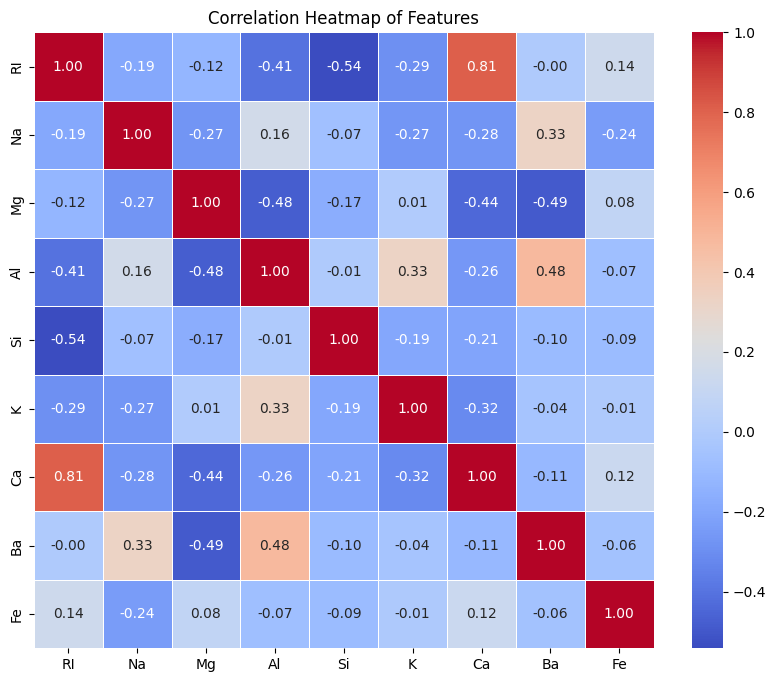

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use original dataset without scaling
corr_matrix = df_original.drop(columns=["Id", "Type of glass"]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Features")
plt.show()

## 2D Subspace Clustering Analysis (ARI)

In [55]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
import itertools
import pandas as pd

results = []

for combo in itertools.combinations(df_scaled.columns, 2):
    X = df_scaled[list(combo)]

    model = DBSCAN(eps=0.5, min_samples=5)
    labels = model.fit_predict(X)

    # Number of clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Skip useless ones
    if n_clusters <= 1:
        continue

    # ARI score
    ari = adjusted_rand_score(true_labels, labels)

    # Noise count
    noise = list(labels).count(-1)

    results.append({
        "Features": combo,
        "Clusters": n_clusters,
        "Noise": noise,
        "ARI": ari
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Sort from best to worst
df_results = df_results.sort_values(by="ARI", ascending=False)

# Show top results
print(df_results.head(10))

    Features  Clusters  Noise       ARI
13  (Mg, Ca)         3     25  0.242390
6   (Na, Mg)         2     16  0.211854
11  (Mg, Si)         2     17  0.206441
0   (RI, Mg)         2     20  0.200995
10  (Mg, Al)         3      4  0.192641
12   (Mg, K)         2      9  0.191438
15  (Mg, Fe)         2      9  0.184758
19  (Si, Ba)         4     12  0.175744
21   (K, Ba)         3      9  0.164282
17  (Al, Ba)         3     10  0.153526


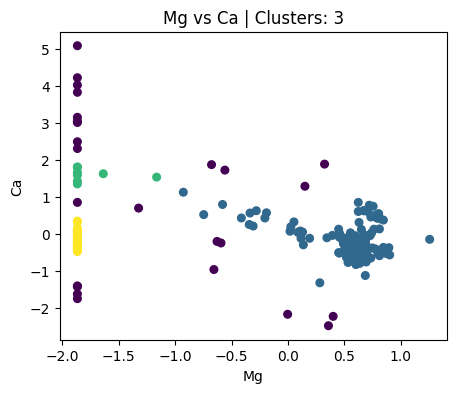

In [58]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Select features
features = ["Mg", "Ca"]
X = df_scaled[features]

# DBSCAN
model = DBSCAN(eps=0.5, min_samples=5)
labels = model.fit_predict(X)

# Cluster count
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Plot
plt.figure(figsize=(5,4))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, s=30)
plt.xlabel("Mg")
plt.ylabel("Ca")
plt.title(f"Mg vs Ca | Clusters: {n_clusters}")
plt.show()

In [64]:
from sklearn.cluster import KMeans
import pandas as pd

# Best 2D subspace
best_2d = ["Mg", "Ca"]

# Select features
X_sub = df_scaled[best_2d]

# Run KMeans
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_sub)

# Crosstab comparison
comparison = pd.crosstab(df_original["Type of glass"], cluster_labels)

comparison

col_0,0,1,2,3,4,5
Type of glass,,,,,,
1,0,51,0,0,19,0
2,0,58,7,4,6,1
3,0,15,0,0,2,0
5,2,0,0,8,2,1
6,2,0,0,3,4,0
7,23,1,0,0,3,2


## 3D Subspace Clustering Analysis (ARI)

In [56]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
import itertools
import pandas as pd

results_3d = []

# Generate all 3D combinations
for combo in itertools.combinations(df_scaled.columns, 3):
    X = df_scaled[list(combo)]

    model = DBSCAN(eps=0.5, min_samples=5)
    labels = model.fit_predict(X)

    # Number of clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Skip weak ones
    if n_clusters <= 1:
        continue

    # ARI score
    ari = adjusted_rand_score(true_labels, labels)

    # Noise points
    noise = list(labels).count(-1)

    results_3d.append({
        "Features": combo,
        "Clusters": n_clusters,
        "Noise": noise,
        "ARI": ari
    })

# Convert to DataFrame
df_results_3d = pd.DataFrame(results_3d)

# Sort best → worst
df_results_3d = df_results_3d.sort_values(by="ARI", ascending=False)

# Show top 10
print(df_results_3d.head(10))

        Features  Clusters  Noise       ARI
51   (Mg, Si, K)         2     40  0.274244
7   (RI, Mg, Si)         3     45  0.268971
65   (Al, K, Ca)         3     39  0.267385
29  (Na, Mg, Ca)         2     48  0.267224
47   (Mg, Al, K)         5     21  0.266332
8    (RI, Mg, K)         4     41  0.263618
48  (Mg, Al, Ca)         2     43  0.259743
27  (Na, Mg, Si)         2     45  0.257336
55   (Mg, K, Ca)         4     35  0.254653
0   (RI, Na, Mg)         2     49  0.249554


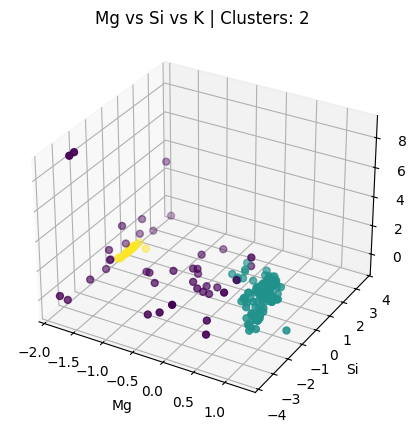

In [61]:
# Select features
features = ["Mg", "Si", "K"]
X = df_scaled[features]

# DBSCAN
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.5, min_samples=5)
labels = model.fit_predict(X)

# Cluster count
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# 3D Plot
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    X.iloc[:,2],
    c=labels,
    s=25
)

ax.set_xlabel("Mg")
ax.set_ylabel("Si")
ax.set_zlabel("K")

ax.set_title(f"Mg vs Si vs K | Clusters: {n_clusters}")
plt.show()

In [65]:
from sklearn.cluster import KMeans
import pandas as pd

# Best 3D subspace
best_3d = ["Mg", "Si", "K"]

# Select features
X_sub = df_scaled[best_3d]

# Run KMeans
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_sub)

# Crosstab comparison
comparison = pd.crosstab(df_original["Type of glass"], cluster_labels)

comparison

col_0,0,1,2,3,4,5
Type of glass,,,,,,
1,24,0,46,0,0,0
2,14,6,51,0,1,4
3,6,0,11,0,0,0
5,1,5,3,2,1,1
6,2,3,2,0,2,0
7,1,23,2,0,1,2


## 4D Subspace Clustering Analysis (ARI)

In [62]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
import itertools
import pandas as pd

results_4d = []

for combo in itertools.combinations(df_scaled.columns, 4):
    X = df_scaled[list(combo)]

    labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    ari = adjusted_rand_score(true_labels, labels)

    results_4d.append({
        "Features": combo,
        "Clusters": n_clusters,
        "Noise": noise,
        "ARI": ari
    })

df_results_4d = pd.DataFrame(results_4d)
df_results_4d = df_results_4d.sort_values(by="ARI", ascending=False)

df_results_4d.head(10)


,Features,Clusters,Noise,ARI
66,"(Na, Mg, K, Ba)",4,43,0.262234
102,"(Mg, Si, K, Ba)",3,48,0.258007
107,"(Mg, K, Ca, Ba)",5,41,0.250389
30,"(RI, Mg, K, Ca)",4,52,0.249974
65,"(Na, Mg, K, Ca)",3,52,0.249768
93,"(Mg, Al, Si, Ba)",5,47,0.247722
96,"(Mg, Al, K, Ba)",5,32,0.246870
57,"(Na, Mg, Al, K)",4,54,0.246008
52,"(RI, K, Ca, Ba)",5,46,0.245870
95,"(Mg, Al, K, Ca)",4,52,0.244846


In [63]:
from sklearn.cluster import KMeans
import pandas as pd

# Best 4D subspace
best_4d = ["Na", "Mg", "K", "Ba"]

# Select 4D features from scaled data
X_sub = df_scaled[best_4d]

# Run KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_sub)

# Create comparison table with actual glass types
comparison = pd.crosstab(df_original["Type of glass"], cluster_labels)

comparison

col_0,0,1,2,3,4,5
Type of glass,,,,,,
1,19,0,0,51,0,0
2,9,0,1,56,5,5
3,6,0,0,11,0,0
5,0,2,1,2,3,5
6,4,0,0,0,5,0
7,1,0,12,2,13,1
